<a href="https://colab.research.google.com/github/guanghen/ResNet50_Image_Classification/blob/main/CSCI325_Final_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Course: CS325 Machine Learning
# Author: Jiaxiang Xie
# Date: December 2025

from google.colab import drive
import os

# Google Colab is a temporary environment. We mount Google Drive
# to access the persistent dataset stored in 'CS325_Project'
# and to save training results (models, logs) so they are not lost.

# Check if Drive is already mounted to avoid redundant prompts
if not os.path.exists('/content/drive'):
    print("Mounting Google Drive to /content/drive...")
    drive.mount('/content/drive')
else:
    print("Google Drive is already mounted.")




Mounting Google Drive to /content/drive...
Mounted at /content/drive
The project path is: /content/drive/MyDrive/CS325_Project


In [ ]:
PROJECT_PATH = '/content/drive/MyDrive/CS325_Project'
print(f"The project path is: {PROJECT_PATH}")

#Check if the folder for Project exists
if not os.path.exists(PROJECT_PATH):
    print(f"Creating the project folder at: {PROJECT_PATH}")
    os.makedirs(PROJECT_PATH)
else:
    print(f"The project folder already exists at: {PROJECT_PATH}")

#Change the working path to our project path
os.chdir(PROJECT_PATH)
print(f"The current working path is: {os.getcwd()}")

The project path is: /content/drive/MyDrive/CS325_Project
The project folder already exists at: /content/drive/MyDrive/CS325_Project
The current working path is: /content/drive/MyDrive/CS325_Project


In [ ]:
import torch

# Set to True if you need to download the dataset from scratch.
# Set to False if images are already downloaded in Google Drive.
DOWNLOAD_DATASET = False

if DOWNLOAD_DATASET:
  print("Begin downloading annotation file from COCO 2017")
  !wget -c http://images.cocodataset.org/annotations/annotations_trainval2017.zip
  print("Begin Unziping the file")
  !unzip -n -q annotations_trainval2017.zip
  print("All done")


In [ ]:
import pandas as pd
from pycocotools.coco import COCO
import numpy as np

dataDir = '.'
dataType = 'train2017'
annFile = '{}/annotations/instances_{}.json'.format(dataDir, dataType)
coco = COCO(annFile)

#The 5 class I want to predict is 'bicycle', 'cat', 'banana', 'bed', 'traffic light'
target_classes = ['bicycle', 'cat', 'banana', 'bed', 'traffic light']

#Get the ID for these 5 instance
target_ids = coco.getCatIds(catNms=target_classes)

# Create a dictionary that have the name of category based on its id
id_to_name = {cat['id']: cat['name'] for cat in coco.loadCats(target_ids)}

imgIds = set()
for target_id in target_ids:
  #getImgIds will return all the img id for this category id
  imgIds.update(coco.getImgIds(catIds=[target_id]))

imgIds = list(imgIds)
print(f"There are {len(imgIds)} images that are related to our class in this dataset")

#Create a csv file to store the information of these image
data = []
for img_id in imgIds:
  # Get the information of this image
  img_info = coco.loadImgs(img_id)[0]
  anno_ids = coco.getAnnIds(imgIds=img_id)
  anns = coco.loadAnns(anno_ids)
  current_img_cats = set()

  # Get the annotation information of this images
  for ann in anns:
    if ann['category_id'] in target_ids: # If the category of this img is the same as the category we want, convert to name and put it in current_img_cats
      current_img_cats.add(id_to_name[ann['category_id']])

 # Ensuring that this image really has the category we want
  if len(current_img_cats) > 0:
        row = {
            'img_id': img_id,
            'file_name': img_info['file_name'],
            'coco_url': img_info['coco_url'],
        }
        # If this img has this category, put 1 else put 0
        for cls in target_classes:
            row[cls] = 1 if cls in current_img_cats else 0

        data.append(row)

df = pd.csv = pd.DataFrame(data)

csv_path = '/content/drive/MyDrive/CS325_Project/dataset_manifest.csv'

# If the csv has not yet been created, create it on csv_path
if not os.path.exists(csv_path):
  df.to_csv(csv_path, index=False)
  print(f"CSV file created at: {csv_path}")

print("The total number of images for each category:")
print(df[target_classes].sum())





loading annotations into memory...
Done (t=22.25s)
creating index...
index created!
There are 16214 images that are related to our class in this dataset
The total number of images for each category:
bicycle          3252
cat              4114
banana           2243
bed              3682
traffic light    4139
dtype: int64


In [ ]:
import requests
from tqdm import tqdm
import os
import pandas as pd
import numpy as np

# Decide the path to download the images
project_path = '/content/drive/MyDrive/CS325_Project'
csv_path = f'{project_path}/dataset_manifest.csv'
image_dir = f'{project_path}/images'

if not os.path.exists(image_dir):
    os.makedirs(image_dir)

df = pd.read_csv(csv_path)

# Download 300 images for each category
SAMPLES_PER_CLASS = 300
target_classes = ['bicycle', 'cat', 'banana', 'bed', 'traffic light']

# Create an empty dataframe to store the image we are going to download
balanced_df = pd.DataFrame()

for cls in target_classes:
  class_df = df[df[cls] == 1]

  #if the number of this image is not enough, we take them all
  if len(class_df) > 0:
      n = min(len(class_df), SAMPLES_PER_CLASS)
      sampled = class_df.sample(n, random_state=42)
      balanced_df = pd.concat([balanced_df, sampled])

# Remove the duplicated rows
balanced_df = balanced_df.drop_duplicates(subset=['img_id'])

success_count = 0
for index, row in tqdm(balanced_df.iterrows(), total=balanced_df.shape[0]):
    img_url = row['coco_url']
    file_name = row['file_name']
    save_path = os.path.join(image_dir, file_name)
    # If we have downloaded this image before, skip this image
    if not os.path.exists(save_path):
        try:
            response = requests.get(img_url, timeout=10)
            if response.status_code == 200:
                with open(save_path, 'wb') as f:
                    f.write(response.content)
                success_count += 1
        except Exception as e:
            pass
    else:
        success_count += 1

print(f"\nDownload finished. There are {success_count} images stored in {image_dir}")

# create a new csv for these image
if not os.path.exists(f'{project_path}/dataset_manifest_cleaned.csv'):
  balanced_df.to_csv(f'{project_path}/dataset_manifest_cleaned.csv', index=False)

print(f"The total number of row in dataset_manifest_cleaned.csv is: {len(balanced_df)}")
print(f"The total number of images for each category:")
print(balanced_df[target_classes].sum())




100%|██████████| 1493/1493 [00:00<00:00, 2775.63it/s]


Download finished. There are 1493 images stored in /content/drive/MyDrive/CS325_Project/images
The total number of row in dataset_manifest_cleaned.csv is: 1493
The total number of images for each category:
bicycle          339
cat              348
banana           311
bed              333
traffic light    334
dtype: int64


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image  # Library for loading images
import os
import pandas as pd
import numpy as np

# 1. Define the Custom Dataset Class
class COCODataset(Dataset):
    """
    Custom PyTorch Dataset class to load and process COCO images.
    """
    def __init__(self, csv_file, root_dir, transform=None):

        self.annotations = pd.read_csv(csv_file)  # Load the CSV manifest
        self.root_dir = root_dir                  # Path to the image directory
        self.transform = transform                # Image preprocessing functions

        # Define the 5 specific target classes (Must match columns in the CSV)
        self.classes = ['bicycle', 'cat', 'banana', 'bed', 'traffic light']

    def __len__(self):
        """
        Returns the total number of samples in the dataset.
        """
        return len(self.annotations)

    def __getitem__(self, index):
        """
        Retrieves the image and label at the specified index.
        """
        # Get the row data for the given index
        row = self.annotations.iloc[index]

        # Construct the full image file path
        img_path = os.path.join(self.root_dir, row['file_name'])

        # Load image and convert to RGB to ensure 3 channels (handling grayscale images)
        image = Image.open(img_path).convert("RGB")


        # Extract the binary labels for the target classes
        labels = row[self.classes]

        # Convert to numpy array with float32 type
        labels = np.array(labels, dtype=np.float32)

        # Apply image transformations (e.g., resizing, normalization) if defined
        if self.transform:
            image = self.transform(image)

        # Convert labels to PyTorch tensor
        labels = torch.tensor(labels)

        return image, labels


# Define Image Preprocessing Pipeline
# We resize images to 224x224 to match ResNet input requirements
# and convert them to PyTorch Tensors.
my_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to standard input size
    transforms.ToTensor(),          # Convert image to Tensor (scales pixels to 0-1)
])

print("Custom Dataset class defined successfully.")

Custom Dataset class defined successfully.


In [ ]:
from torch.utils.data import DataLoader, random_split

project_path = '/content/drive/MyDrive/CS325_Project'
cleaned_csv_path = f'{project_path}/dataset_manifest_cleaned.csv'
image_dir = f'{project_path}/images'
full_dataset = COCODataset(csv_file=cleaned_csv_path, root_dir=image_dir, transform=my_transform)

# Divide the images for train and validation. (80% for training and 20% for testing)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

print(f"Total images number: {len(full_dataset)}")
print(f"Train set number: {train_size}")
print(f"Test set number: {val_size}")

# 3. cut it randomly
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)



Total images number: 1493
Train set number: 1194
Test set number: 299


In [ ]:
import torch.nn as nn
from torchvision import models
import torch


# Load the pre-trained ResNet50 model
# This utilizes Transfer Learning to leverage learned feature representations.
print("Loading pre-trained ResNet50 model...")
model = models.resnet50(weights='DEFAULT')

# Modify the Final Classification Layer
# We need to adapt the final fully connected layer (fc) for our 5 target classes.

# Retrieve the number of input features of the last layer
num_features = model.fc.in_features

# Replace the fully connected layer
# We define a new Linear layer with 'num_features' inputs and 5 outputs.
model.fc = nn.Linear(num_features, 5)

# 3. Move the model to the GPU
# Check if CUDA is available to accelerate training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Model successfully modified and moved to device: {device}")


Loading pre-trained ResNet50 model...
Model successfully modified and moved to device: cuda


In [ ]:
import torch.optim as optim
import time


# Define Hyperparameters
# Set the Learning Rate to control the step size during gradient descent.
learning_rate = 0.001
num_epochs = 5  # Number of complete passes through the training dataset

# Define Loss Function
criterion = nn.BCEWithLogitsLoss()

# Define Optimizer
# We use the Adam optimizer, which computes adaptive learning rates for each parameter.
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Dictionary to store performance metrics for visualization/reporting
history = {
    'train_loss': [],
    'val_loss': [],
    'val_acc': []
}

print(f"Starting training for {num_epochs} epochs...")
start_time = time.time()

for epoch in range(num_epochs):


    # Training
    model.train()  # Set the model to training mode (enables Dropouts/BatchNorm updates)
    running_loss = 0.0

    for images, labels in train_loader:
        # Move data to the configured device (GPU/CPU)
        images, labels = images.to(device), labels.to(device)

        # Zero the parameter gradients to prevent accumulation
        optimizer.zero_grad()

        # Forward Pass: Compute predicted outputs by passing inputs to the model
        outputs = model(images)

        # Compute Loss: Calculate the difference between predictions and actual labels
        loss = criterion(outputs, labels)

        # Backward Pass: Compute gradients of the loss with respect to model parameters
        loss.backward()

        # Optimization Step: Update model parameters based on gradients
        optimizer.step()

        running_loss += loss.item()

    # Calculate average training loss for the epoch
    avg_train_loss = running_loss / len(train_loader)


    # Validation
    model.eval()  # Set the model to evaluation mode
    val_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Disable gradient calculation for validation to save memory and computation
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)

            # Compute validation loss
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # Calculate Accuracy
            # Apply Sigmoid to convert raw logits to probabilities (0 to 1)
            probs = torch.sigmoid(outputs)

            # Convert probabilities to binary predictions (Threshold = 0.5)
            preds = (probs > 0.5).float()

            # Calculate metrics
            # We count total individual predictions (5 classes per image)
            total_samples += labels.size(0) * 5
            correct_predictions += (preds == labels).sum().item()

    # Calculate average validation statistics
    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = correct_predictions / total_samples

    # Update history dictionary
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_accuracy)

    # Print epoch summary
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Acc: {val_accuracy*100:.2f}%")

total_time = time.time() - start_time
print(f"\n Training complete! Total duration: {total_time:.0f} seconds")

Starting training for 5 epochs...
Epoch [1/5] Train Loss: 0.3191 | Val Loss: 0.8276 | Val Acc: 79.06%
Epoch [2/5] Train Loss: 0.2160 | Val Loss: 0.3518 | Val Acc: 86.02%
Epoch [3/5] Train Loss: 0.1922 | Val Loss: 0.3897 | Val Acc: 84.15%
Epoch [4/5] Train Loss: 0.1365 | Val Loss: 0.3552 | Val Acc: 85.75%
Epoch [5/5] Train Loss: 0.0999 | Val Loss: 0.6188 | Val Acc: 83.48%

 Training complete! Total duration: 361 seconds


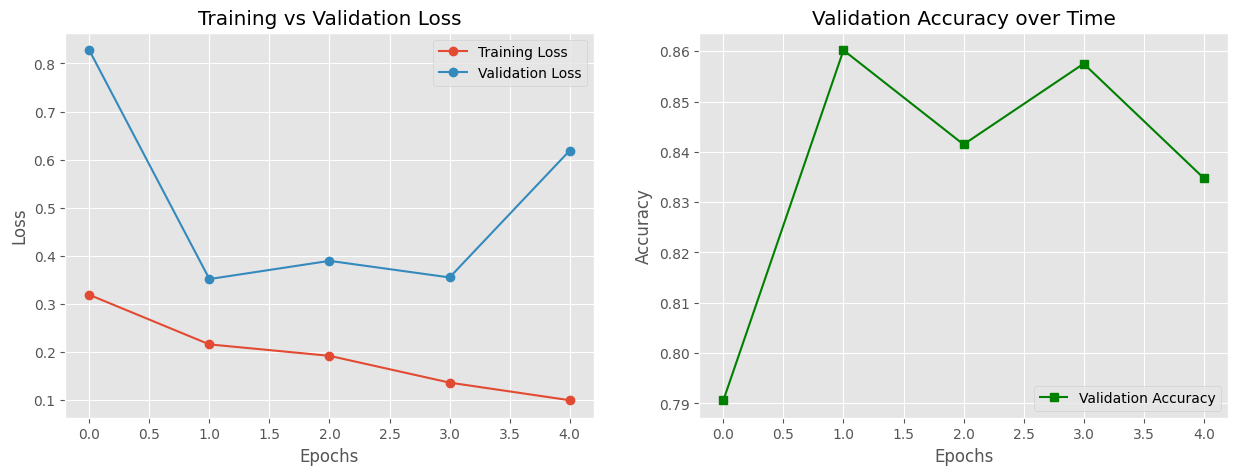

In [ ]:
import matplotlib.pyplot as plt

# Set the Style for the diagram
plt.style.use('ggplot')

# Create one big diagram and put 2 sub diagram inside it
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss Curve
ax1.plot(history['train_loss'], label='Training Loss', marker='o')
ax1.plot(history['val_loss'], label='Validation Loss', marker='o')
ax1.set_title('Training vs Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy Curve
ax2.plot(history['val_acc'], label='Validation Accuracy', color='green', marker='s')
ax2.set_title('Validation Accuracy over Time')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.show()

Selecting 3 random images for detailed inspection...

Image ID: 119
Ground Truth: ['bicycle']
Model Confidence Scores (Threshold > 0.5):
----------------------------------------
   bicycle        : 0.5985 ( YES)
   cat            : 0.0144 ( NO )
   banana         : 0.0687 ( NO )
   bed            : 0.1494 ( NO )
   traffic light  : 0.0631 ( NO )
----------------------------------------


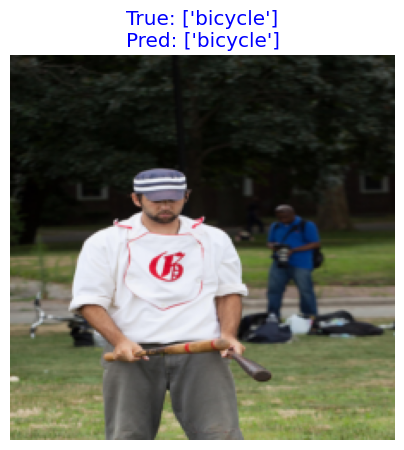


Image ID: 201
Ground Truth: ['bed']
Model Confidence Scores (Threshold > 0.5):
----------------------------------------
   bicycle        : 0.0008 ( NO )
   cat            : 0.0008 ( NO )
   banana         : 0.0000 ( NO )
   bed            : 0.9999 ( YES)
   traffic light  : 0.0002 ( NO )
----------------------------------------


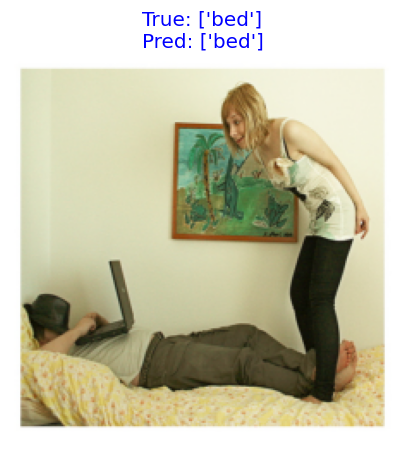


Image ID: 75
Ground Truth: ['banana']
Model Confidence Scores (Threshold > 0.5):
----------------------------------------
   bicycle        : 0.0001 ( NO )
   cat            : 0.0011 ( NO )
   banana         : 0.9994 ( YES)
   bed            : 0.0003 ( NO )
   traffic light  : 0.0001 ( NO )
----------------------------------------


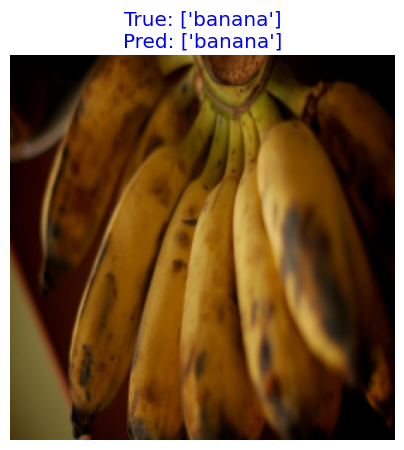

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

def show_prediction_with_probs(index):

    # Retrieve Data
    # Get the image tensor and label tensor from the validation dataset
    image, label = val_dataset[index]

    # Perform Inference (Prediction)
    model.eval()
    with torch.no_grad():
        # Add batch dimension (Batch size = 1) and move to device
        image_tensor = image.unsqueeze(0).to(device)

        # Forward pass
        output = model(image_tensor)

        # Calculate probabilities using Sigmoid
        probs = torch.sigmoid(output)

        # Convert to numpy array for processing
        probs_np = probs.cpu().numpy()[0]

    # Prepare Image for Display
    # Undo the channel permutation (C, H, W) -> (H, W, C) for Matplotlib
    img_display = image.permute(1, 2, 0).numpy()
    class_names = ['bicycle', 'cat', 'banana', 'bed', 'traffic light']

    # Extract Ground Truth Labels
    true_labels = [class_names[i] for i, x in enumerate(label.numpy()) if x == 1]

    # Print Detailed Prediction Report
    print(f"\nImage ID: {index}")
    print(f"Ground Truth: {true_labels}")
    print("Model Confidence Scores (Threshold > 0.5):")
    print("-" * 40)

    pred_labels = []
    for i, name in enumerate(class_names):
        score = probs_np[i]

        # Determine status based on threshold
        status = " YES" if score > 0.5 else " NO "

        if score > 0.5:
            pred_labels.append(name)

        # Print formatted score
        print(f"   {name.ljust(15)}: {score:.4f} ({status})")

    print("-" * 40)

    # Visualize Result
    plt.figure(figsize=(5,5))
    plt.imshow(img_display)
    plt.axis('off')

    # Set title with ground truth and predictions
    plt.title(f"True: {true_labels}\nPred: {pred_labels}", color='blue')
    plt.show()


# Inference Demonstration
# Select 3 random samples from the validation set to inspect detailed predictions
print("Selecting 3 random images for detailed inspection...")
indices = random.sample(range(len(val_dataset)), 3)

for idx in indices:
    show_prediction_with_probs(idx)